<a href="https://colab.research.google.com/github/ChronosXV/Aprendizaje-Automatico/blob/main/Grupo_Nro_02_Consumo_Digital_en_Adolescentes.ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Consumo Digital en Adolescentes

##Integrantes del grupo:

* Gisela Martinez
* Noelia Cualina
* José Leonardo Carabajal
* Javier Carabajal

# Análisis Exploratorio de Datos y preparación para Aprendizaje No Supervisado

**Materia:** Aprendizaje Automático  
**Objetivo del notebook:** realizar un EDA completo, documentar las decisiones de limpieza y preprocesamiento, construir un dataset limpio y preparar las variables para un problema de **clustering**.

### Pregunta de investigación

> **¿Es posible identificar perfiles diferenciados de adolescentes según sus patrones de uso de pantallas mediante técnicas de aprendizaje automático no supervisado y caracterizar dichos perfiles a partir de sus hábitos y características?**

### Enfoque general

El dataset contiene información sobre adolescentes, características demográficas, uso de pantallas, uso de dispositivos, sueño, somnolencia y rendimiento académico. El objetivo no es predecir una etiqueta conocida, sino descubrir grupos naturales de adolescentes con patrones de comportamiento digital semejantes.

Se distinguirán dos tipos de variables:

- **Variables de clusterización:** intervienen directamente en la formación de los grupos.
- **Variables de caracterización:** se utilizan después para comprender e interpretar los grupos encontrados.

El análisis es **exploratorio y descriptivo**. Las asociaciones observadas no deben interpretarse como relaciones causales.

# 1. Introducción

El uso de dispositivos electrónicos, redes sociales, videojuegos y servicios de televisión o streaming forma parte de la vida cotidiana de los adolescentes. Sin embargo, el comportamiento digital no es homogéneo: dos adolescentes pueden acumular una cantidad similar de horas de exposición a pantallas y, aun así, distribuir ese tiempo de manera muy diferente entre redes sociales, videojuegos, juegos en dispositivos móviles, contenido audiovisual u otras actividades.

Por esta razón, observar únicamente el **tiempo total de pantalla** puede ocultar patrones relevantes. El propósito de este trabajo es utilizar técnicas de **Aprendizaje Automático No Supervisado** para identificar perfiles naturales de comportamiento digital.

Los grupos serán formados a partir de variables relacionadas con el uso de pantallas. Posteriormente, se utilizarán variables demográficas, de sueño, somnolencia y rendimiento académico para caracterizar los perfiles obtenidos.

### Beneficios esperados

La segmentación puede ayudar a:

- comprender la heterogeneidad de los patrones de consumo digital;
- identificar perfiles predominantes dentro de la población adolescente;
- describir diferencias entre grupos;
- orientar investigaciones posteriores;
- aportar evidencia para estrategias diferenciadas de educación, prevención, concientización o comunicación.

El objetivo no es demostrar causalidad entre uso de pantallas, sueño o desempeño académico, sino descubrir perfiles y explorar asociaciones.

# 2 Librerías y configuración

In [1]:
# Ejecutamos el comando git clone y descargamos nuestro
!git clone https://{git_token}@github.com/ChronosXV/Aprendizaje-Automatico.git

Cloning into 'Aprendizaje-Automatico'...
remote: Enumerating objects: 73, done.
remote: Counting objects: 100% (73/73), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 73 (delta 25), reused 21 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (73/73), 17.49 MiB | 30.93 MiB/s, done.
Resolving deltas: 100% (25/25), done.


In [2]:
# Librerías principales
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)
from sklearn.decomposition import PCA
from google.colab import files

# warnings.filterwarnings("default")

# RANDOM_STATE = 42

# pd.set_option("display.max_columns", 150)
# pd.set_option("display.max_rows", 200)
# pd.set_option("display.max_colwidth", 120)

# plt.rcParams["figure.figsize"] = (10, 5)
# plt.rcParams["axes.grid"] = True

# 3 Carga del dataset

El archivo original contiene múltiples variables originales, recodificadas, categorizadas y derivadas. Por ese motivo se conservará una copia inalterada (`df_original`) y se trabajará sobre una copia (`df`).

In [3]:
# Extraccion y tranformacion del conjunto de datos
path="/content/Aprendizaje-Automatico/tp1/repositorio.xlsx"
df_original = pd.read_excel(path)
df = df_original.copy()

display(df.head())

,IP,Submission ID,Submission Date,Código,investigador,Colegio,Ciudad,grado,edad,Fecha de nacimiento,...,matematica,prom,aplazos,datoscompletoDEMOG,datoscompletoSUENO,datoscompletoPANTALLAS,excSUENOpantallas,excluidos,missingnotas,excluFINAL
0,181.45.234.85,4363218715845085057,2019-06-14 09:44:31,01 01 01 1 1 AS 0 170407,1,1,1,1,NaN,0007-04-18 00:00:00,...,NaN,NaN,NaN,0,1,0,1,1,1,1
1,181.45.234.85,4363225955846355489,2019-06-14 09:56:35,01 01 01 1 1 AS 1 240107,1,1,1,1,12.0,2007-01-24 00:00:00,...,NaN,NaN,NaN,1,1,1,0,0,1,1
2,181.45.234.85,4363219855845435174,2019-06-14 09:46:25,01 01 01 1 1 bk 1 151006,1,1,1,1,13.0,2006-10-15 00:00:00,...,NaN,NaN,NaN,1,1,1,0,0,1,1
3,181.45.234.85,4363218145845601010,2019-06-14 09:43:34,01 01 01 1 1 CG 0 051006,1,1,1,1,13.0,2006-10-05 00:00:00,...,NaN,NaN,NaN,1,1,0,1,1,1,1
4,181.45.234.85,4363224915847071805,2019-06-14 09:54:51,01 01 01 1 1 EQ 1 230505,1,1,1,1,NaN,0005-05-24 00:00:00,...,NaN,NaN,NaN,0,0,1,1,1,1,1


In [4]:
display(Markdown(f'''
### Resultado inicial

El archivo cargado contiene **{df.shape[0]:,} registros** y **{df.shape[1]:,} variables**.

En las siguientes secciones se evaluará la calidad de los datos antes de decidir qué registros y variables serán utilizados para el análisis.
'''))


### Resultado inicial

El archivo cargado contiene **4,115 registros** y **125 variables**.

En las siguientes secciones se evaluará la calidad de los datos antes de decidir qué registros y variables serán utilizados para el análisis.


# 4 Comprensión inicial del dataset

In [5]:
# Exploración inicial de la estructura del dataset:
# revisamos los tipos de datos, algunas columnas representativas
# y el uso aproximado de memoria.
print("Tipos de datos:")
display(df.dtypes.value_counts().rename("cantidad").to_frame())

print("\nPrimeras 10 columnas:")
display(pd.DataFrame({"columna": df.columns[:10]}))

print("\nÚltimas 10 columnas:")
display(pd.DataFrame({"columna": df.columns[-10:]}))

print("\nUso aproximado de memoria:")
mem_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"{mem_mb:.2f} MB")

Tipos de datos:


,cantidad
float64,66
int64,37
object,21
datetime64[ns],1



Primeras 10 columnas:


,columna
0,IP
1,Submission ID
2,Submission Date
3,Código
4,investigador
5,Colegio
6,Ciudad
7,grado
8,edad
9,Fecha de nacimiento



Últimas 10 columnas:


,columna
0,matematica
1,prom
2,aplazos
3,datoscompletoDEMOG
4,datoscompletoSUENO
5,datoscompletoPANTALLAS
6,excSUENOpantallas
7,excluidos
8,missingnotas
9,excluFINAL



Uso aproximado de memoria:
7.91 MB


In [6]:
# Auditoría general de variables:
# clasificamos cada columna según su tipo semántico y resumimos
# completitud, valores únicos y porcentaje de datos faltantes.
def tipo_semantico(nombre, serie):
    n = str(nombre).lower()

    if any(x in n for x in ["id", "ip", "código", "codigo", "submission"]):
        return "identificador/administrativa"
    if any(x in n for x in ["fecha", "date"]):
        return "fecha/temporal"
    if any(x in n for x in ["porc"]):
        return "porcentaje derivado"
    if any(x in n for x in ["trimmed", "strimmed", "strimed", "strimeed"]):
        return "variable tratada/trimmed"
    if re.search(r"01$", n):
        return "indicador binario"
    if any(x in n for x in ["cat"]):
        return "categórica derivada"
    if any(x in n for x in ["recod", "proc"]):
        return "recodificada/procesada"
    if pd.api.types.is_numeric_dtype(serie):
        return "numérica"
    return "categórica/texto"

resumen_variables = pd.DataFrame({
    "variable": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "no_nulos": [df[c].notna().sum() for c in df.columns],
    "nulos": [df[c].isna().sum() for c in df.columns],
    "porcentaje_nulos": [df[c].isna().mean() * 100 for c in df.columns],
    "valores_unicos": [df[c].nunique(dropna=True) for c in df.columns],
})

resumen_variables["porcentaje_unicos"] = (
    resumen_variables["valores_unicos"] / len(df) * 100
)

resumen_variables["tipo_semantico"] = [
    tipo_semantico(c, df[c]) for c in df.columns
]

display(resumen_variables)

,variable,dtype,no_nulos,nulos,porcentaje_nulos,valores_unicos,porcentaje_unicos,tipo_semantico
0,IP,object,4115,0,0.0,1120,27.217497,identificador/administrativa
1,Submission ID,int64,4115,0,0.0,4115,100.000000,identificador/administrativa
2,Submission Date,datetime64[ns],4115,0,0.0,4029,97.910085,identificador/administrativa
3,Código,object,4115,0,0.0,4114,99.975699,identificador/administrativa
4,investigador,int64,4115,0,0.0,29,0.704739,numérica
...,...,...,...,...,...,...,...,...
120,datoscompletoPANTALLAS,int64,4115,0,0.0,2,0.048603,numérica
121,excSUENOpantallas,int64,4115,0,0.0,2,0.048603,numérica
122,excluidos,int64,4115,0,0.0,2,0.048603,identificador/administrativa
123,missingnotas,int64,4115,0,0.0,2,0.048603,numérica


In [7]:
# Identificamos las variables con mayor porcentaje de valores faltantes
# para evaluar posteriormente su conservación o exclusión.
display(
    resumen_variables
    .sort_values("porcentaje_nulos", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

,variable,dtype,no_nulos,nulos,porcentaje_nulos,valores_unicos,porcentaje_unicos,tipo_semantico
0,WAZ,float64,27,4088,99.343864,27,0.656136,numérica
1,prom,float64,1257,2858,69.453220,61,1.482382,numérica
2,aplazos,float64,1257,2858,69.453220,2,0.048603,numérica
3,matematica,float64,1257,2858,69.453220,31,0.753341,numérica
4,lengua,float64,1261,2854,69.356015,28,0.680437,numérica
5,tpotvonlinePORC,float64,2969,1146,27.849332,1053,25.589307,porcentaje derivado
6,tpotabletPORC,float64,2969,1146,27.849332,984,23.912515,porcentaje derivado
7,tporedesPORC,float64,2969,1146,27.849332,1173,28.505468,porcentaje derivado
8,tpovideojuegosPORC,float64,2969,1146,27.849332,656,15.941677,identificador/administrativa
9,tpootrasPORC,float64,2969,1146,27.849332,622,15.115431,porcentaje derivado


In [8]:
# Resumen del DF
n_num = df.select_dtypes(include=np.number).shape[1]
n_obj = df.select_dtypes(include=["object", "category"]).shape[1]
n_dt = df.select_dtypes(include=["datetime", "datetimetz"]).shape[1]

display(Markdown(f'''
### Interpretación de la estructura

- Variables numéricas: **{n_num}**
- Variables de texto/categóricas: **{n_obj}**
- Variables de fecha detectadas directamente: **{n_dt}**

El dataset contiene 125 variables, de las cuales 103 son numéricas, 21 corresponden a texto o categorías y 1 fue detectada como fecha. La auditoría evidencia distintos niveles de completitud entre las variables y la presencia de múltiples representaciones de una misma característica, incluyendo versiones originales, recodificadas, categorizadas, binarias, porcentuales y tratadas (trimmed). Por este motivo, será necesario seleccionar las variables de acuerdo con su relevancia para el análisis, su calidad y el posible grado de redundancia entre ellas.
'''))


### Interpretación de la estructura

- Variables numéricas: **103**
- Variables de texto/categóricas: **21**
- Variables de fecha detectadas directamente: **1**

El dataset contiene 125 variables, de las cuales 103 son numéricas, 21 corresponden a texto o categorías y 1 fue detectada como fecha. La auditoría evidencia distintos niveles de completitud entre las variables y la presencia de múltiples representaciones de una misma característica, incluyendo versiones originales, recodificadas, categorizadas, binarias, porcentuales y tratadas (trimmed). Por este motivo, será necesario seleccionar las variables de acuerdo con su relevancia para el análisis, su calidad y el posible grado de redundancia entre ellas.


# 5 Diccionario y clasificación de variables

En esta sección se agrupan variables según patrones de nombres. Esta clasificación no implica que deban eliminarse: sirve para reconocer posibles redundancias y entender cómo fue procesado previamente el dataset.

Esto nos permite:

1.   Identificar redundancias: Podemos ver rápidamente qué variables son
versiones alternativas de una misma información (por ejemplo, tener la duración de sueño original, su versión depurada TRIMMED y su versión categorizada CAT).
2.   Evitar redundancia: Nos ayuda a decidir qué representación conservar de cada característica y cuáles excluir para evitar incorporar información duplicada o sobrerrepresentar determinadas dimensiones en el algoritmo de clustering.

3.  Facilitar la limpieza de datos: Al agrupar variables similares (como todas las binarias 01 o de completitud), podemos aplicarles reglas o transformaciones en bloque de manera mucho más rápida.

In [9]:
# Agrupamos las variables del dataset en familias según los patrones
# de texto en sus nombres

patrones = {
    "recodificadas": r"recod",
    "trimmed": r"trimmed|strimmed|strimed|strimeed",
    "categorizadas": r"cat",
    "porcentajes": r"porc",
    "binarias_01": r"01$",
    "procesadas": r"proc",
    "completitud_exclusion": r"completo|exclu|missing",
}

familias = {}

for nombre_familia, patron in patrones.items():
    familias[nombre_familia] = [
        c for c in df.columns if re.search(patron, c, flags=re.IGNORECASE)
    ]
    print(f"\n### {nombre_familia.upper()} ({len(familias[nombre_familia])})")
    for c in familias[nombre_familia]:
        print("-", c)


### RECODIFICADAS (4)
- FECHA_NAC_RECOD
- niveducpadresRECOD
- cantpersonasviviendaRECOD
- problemasatencionrecod

### TRIMMED (22)
- tposueñosemTRIMMED
- tposueñofsemTRIMMED
- tpopantallatotalhstrimmed
- tpovideojuegoshstrimmed
- tpojuegotabletcelhstrimmed
- tporedeshstrimmed
- tpotvonlinehstrimeed
- tpootrashstrimed
- tpovideojuegoshstrimmedCAT
- tpojuegotabletcelhstrimmedCAT
- tporedeshstrimmedCAT
- tpotvonlinehstrimeedCAT
- tpootrashstrimedCAT
- cantdiascompustrimmed
- cantdiascelulartrimmed
- cantdiastablettrimmed
- cantdiasconsolajuegostrimmed
- cantdiastvtrimmed
- tpovideojuegoshstrimmed01
- tpojuegotabletcelhstrimmed01
- tporedeshstrimmed01
- tpotvonlinehstrimeed01

### CATEGORIZADAS (11)
- ¿Cuál es el máximo nivel educativo alcanzado por tu padre, madre o tutor?
- tposueñosemCAT
- tposueñofsemCAT
- tpopantallatotalhscat
- tpopantallatotalhscat2
- tpovideojuegoshstrimmedCAT
- tpojuegotabletcelhstrimmedCAT
- tporedeshstrimmedCAT
- tpotvonlinehstrimeedCAT
- tpootrashstrimedCAT
-

# 6 Calidad de los datos

## 6.1 Valores faltantes

,nulos,porcentaje
WAZ,4088,99.343864
prom,2858,69.453220
aplazos,2858,69.453220
matematica,2858,69.453220
lengua,2854,69.356015
tpotvonlinePORC,1146,27.849332
tpotabletPORC,1146,27.849332
tporedesPORC,1146,27.849332
tpovideojuegosPORC,1146,27.849332
tpootrasPORC,1146,27.849332


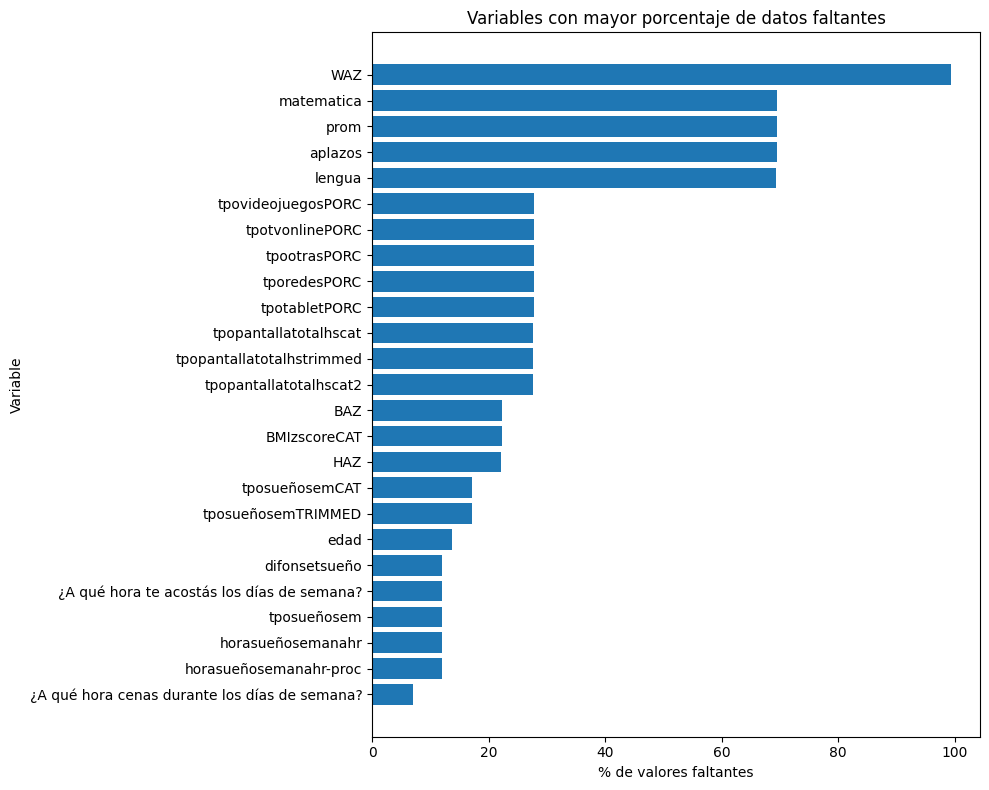

In [10]:
missing = pd.DataFrame({
    "nulos": df.isna().sum(),
    "porcentaje": df.isna().mean() * 100
}).sort_values("porcentaje", ascending=False)

display(missing.head(30))

# Visualización de las variables con mayor porcentaje de faltantes
top_missing = missing.head(25).sort_values("porcentaje")

plt.figure(figsize=(10, 8))
plt.barh(top_missing.index, top_missing["porcentaje"])
plt.xlabel("% de valores faltantes")
plt.ylabel("Variable")
plt.title("Variables con mayor porcentaje de datos faltantes")
plt.tight_layout()
plt.show()

**Interpretación:**

La presencia de valores faltantes no es homogénea entre las variables. Algunas presentan niveles muy elevados de ausencia, mientras que otras conservan una alta proporción de observaciones disponibles. Por este motivo, no se aplicará una estrategia global de eliminación o imputación, sino que el tratamiento dependerá de la función de cada variable dentro del análisis.

### Criterio de tratamiento de faltantes

No se aplicará una única regla global de imputación. La decisión dependerá de la función de la variable:

- Si una variable es indispensable para formar los clusters, se evaluará su proporción de faltantes y la conveniencia de trabajar con casos completos o imputación.
- Si una variable se utiliza solamente para caracterizar clusters, un faltante no necesariamente obliga a excluir el registro del clustering.
- Las variables con porcentajes de faltantes muy elevados serán evaluadas individualmente y podrán excluirse cuando su nivel de completitud no permita un análisis adecuado.

## 6.2 Duplicados

In [11]:
duplicados_exactos = df.duplicated().sum()
print("Filas completamente duplicadas:", duplicados_exactos)

for id_col in ["Submission ID", "Código"]:
    if id_col in df.columns:
        dup = df[id_col].duplicated(keep=False)
        print(f"{id_col}: {dup.sum()} registros involucrados en valores duplicados")
        if dup.any():
            display(df.loc[dup, [id_col]].sort_values(id_col).head(20))

Filas completamente duplicadas: 0
Submission ID: 0 registros involucrados en valores duplicados
Código: 2 registros involucrados en valores duplicados


,Código
2573,10 19 48 2 1 IR 0 131004
2574,10 19 48 2 1 IR 0 131004


**Interpretación de duplicados:**

No se detectaron filas completamente duplicadas ni valores repetidos en Submission ID. Se identificaron dos registros que comparten el mismo valor de Código; sin embargo, al no tratarse de filas idénticas, esta repetición no se considerará por sí sola evidencia suficiente para eliminar registros. El identificador se conserva únicamente con fines de trazabilidad y no será utilizado como variable de entrada para el clustering.

## 6.3 Búsqueda de errores, textos especiales e inconsistencias

In [12]:
# Búsqueda de valores especiales o posibles representaciones textuales
# de errores y datos faltantes en las variables del dataset.
errores_busqueda = [
    "#NAME?", "#VALUE!", "#REF!", "#DIV/0!", "#N/A",
    "Sin información", "sin informacion", "inf", "-inf"
]

hallazgos = []

for c in df.columns:
    s = df[c].astype(str)
    for patron in errores_busqueda:
        mask = s.str.contains(re.escape(patron), case=False, na=False)
        if mask.any():
            hallazgos.append({
                "variable": c,
                "patron": patron,
                "cantidad": int(mask.sum())
            })

hallazgos_df = pd.DataFrame(hallazgos)

if len(hallazgos_df):
    display(hallazgos_df.sort_values("cantidad", ascending=False))
else:
    print("No se encontraron los patrones de error buscados en los valores cargados por pandas.")
    print("Nota: si el Excel contiene fórmulas rotas, pandas puede leer el valor almacenado o NaN dependiendo del archivo.")

,variable,patron,cantidad
0,FECHA_NAC_RECOD,Sin información,535
1,FECHA_NAC_RECOD,inf,535


In [13]:
# Infinitos en variables numéricas
num_cols = df.select_dtypes(include=np.number).columns
inf_counts = {}

for c in num_cols:
    n_inf = np.isinf(df[c].to_numpy(dtype=float, na_value=np.nan)).sum()
    if n_inf > 0:
        inf_counts[c] = int(n_inf)

print("Variables con valores infinitos:")
print(inf_counts if inf_counts else "Ninguna")

Variables con valores infinitos:
Ninguna


**Interpretación:**

La búsqueda no detectó valores infinitos en las variables numéricas. Los patrones "Sin información" e "inf" encontrados en FECHA_NAC_RECOD corresponden a representaciones textuales de información faltante o no disponible. Esta variable no será utilizada como entrada para el clustering, por lo que estos valores no afectan directamente la formación de los grupos.

## 6.4 Indicadores de completitud y exclusión

El dataset incluye indicadores construidos durante el procesamiento original. Estos indicadores se analizarán, pero no se utilizarán ciegamente como filtro, ya que nuestro objetivo de clustering puede requerir criterios diferentes del estudio original.

Nota: En los indicadores de completitud, 0 representa un registro incompleto y 1 un registro completo. Los indicadores de exclusión se interpretarán de acuerdo con su definición original.

In [14]:
# Revisión de los indicadores de completitud y exclusión
# incluidos en el procesamiento original del dataset.
cols_indicadores = [
    "datoscompletoDEMOG",
    "datoscompletoSUENO",
    "datoscompletoPANTALLAS",
    "excSUENOpantallas",
    "excluidos",
    "missingnotas",
    "excluFINAL",
]
cols_indicadores = [c for c in cols_indicadores if c in df.columns]

for c in cols_indicadores:
    print(f"\n{c}")
    display(
        df[c]
        .value_counts(dropna=False)
        .rename("cantidad")
        .to_frame()
        .assign(porcentaje=lambda x: x["cantidad"] / len(df) * 100)
    )


datoscompletoDEMOG


,cantidad,porcentaje
datoscompletoDEMOG,,
1,3553,86.342649
0,562,13.657351



datoscompletoSUENO


,cantidad,porcentaje
datoscompletoSUENO,,
1,3220,78.250304
0,895,21.749696



datoscompletoPANTALLAS


...

,cantidad,porcentaje
excluidos,,
0,2449,59.513973
1,1666,40.486027



missingnotas


,cantidad,porcentaje
missingnotas,,
1,2858,69.45322
0,1257,30.54678



excluFINAL


,cantidad,porcentaje
excluFINAL,,
1,3251,79.003645
0,864,20.996355


**Interpretación:**

Estas variables fueron construidas durante el procesamiento original a partir de información disponible en otras variables del dataset y permiten conocer los criterios de completitud y exclusión utilizados en el estudio de origen. Sin embargo, no se utilizarán automáticamente como filtros ni como variables de entrada para el clustering, ya que el presente trabajo persigue un objetivo diferente: identificar perfiles de consumo digital. La inclusión de registros se determinará en función de la disponibilidad de las variables necesarias para cada etapa del análisis.

# 7 Análisis Exploratorio de Datos

## 7.1 Características demográficas

,edad
count,3553.000000
mean,15.600338
std,1.601527
min,12.000000
1%,12.000000
5%,13.000000
25%,14.000000
50%,16.000000
75%,17.000000
95%,18.000000



Distribución de edad:


,cantidad
edad,
12.0,72
13.0,294
14.0,591
15.0,715
16.0,736
17.0,707
18.0,385
19.0,42
20.0,11


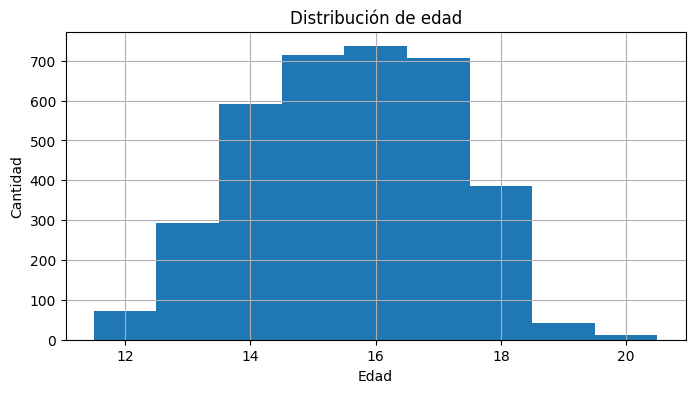

,cantidad
Sexo,
Femenino,2277
Masculino,1838


,cantidad
grado,
1,712
2,761
3,814
4,833
5,745
6,250


In [15]:
# Edad
if "edad" in df.columns:
    display(df["edad"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_frame())

    print("\nDistribución de edad:")
    display(df["edad"].value_counts(dropna=False).sort_index().rename("cantidad").to_frame())

    plt.figure(figsize=(8, 4))
    df["edad"].dropna().hist(bins=range(
        int(df["edad"].dropna().min()),
        int(df["edad"].dropna().max()) + 2
    ), align="left")
    plt.xlabel("Edad")
    plt.ylabel("Cantidad")
    plt.title("Distribución de edad")
    plt.show()

# Sexo
if "Sexo" in df.columns:
    display(df["Sexo"].value_counts(dropna=False).rename("cantidad").to_frame())

# Grado
if "grado" in df.columns:
    display(df["grado"].value_counts(dropna=False).sort_index().rename("cantidad").to_frame())

In [16]:
if "edad" in df.columns:
    menores_12 = int((df["edad"] < 12).sum())
    entre_12_18 = int(df["edad"].between(12, 18, inclusive="both").sum())
    mayores_18 = int((df["edad"] > 18).sum())
    edad_missing = int(df["edad"].isna().sum())

    display(Markdown(f'''
### Interpretación de edad

- Menores de 12 años: **{menores_12}**
- Entre 12 y 18 años: **{entre_12_18}**
- Mayores de 18 años: **{mayores_18}**
- Edad faltante: **{edad_missing}**

La mayor parte de los registros con edad informada corresponde al rango de 12 a 18 años definido para la población de estudio. Se identifican 53 registros con edades superiores a 18 años y 562 registros sin información de edad. Estos resultados serán considerados posteriormente durante la limpieza, donde se aplicará el criterio poblacional definido para el análisis.
'''))


### Interpretación de edad

- Menores de 12 años: **0**
- Entre 12 y 18 años: **3500**
- Mayores de 18 años: **53**
- Edad faltante: **562**

La mayor parte de los registros con edad informada corresponde al rango de 12 a 18 años definido para la población de estudio. Se identifican 53 registros con edades superiores a 18 años y 562 registros sin información de edad. Estos resultados serán considerados posteriormente durante la limpieza, donde se aplicará el criterio poblacional definido para el análisis.


## 7.2 Consumo digital

## Comparación de variables de consumo digital: originales vs. trimmed

In [17]:
vars_consumo_original = [
    "tpovideojuegoshs",
    "tpojuegotabletcelhs",
    "tporedeshs",
    "tpotvonlinehs",
    "tpootrashs",
    "tpopantallatotalhs",
]

vars_consumo_trimmed = [
    "tpovideojuegoshstrimmed",
    "tpojuegotabletcelhstrimmed",
    "tporedeshstrimmed",
    "tpotvonlinehstrimeed",
    "tpootrashstrimed",
    "tpopantallatotalhstrimmed",
]

vars_consumo_original = [c for c in vars_consumo_original if c in df.columns]
vars_consumo_trimmed = [c for c in vars_consumo_trimmed if c in df.columns]

print("Variables originales:")
print(vars_consumo_original)

print("\nVariables tratadas/trimmed:")
print(vars_consumo_trimmed)

Variables originales:
['tpovideojuegoshs', 'tpojuegotabletcelhs', 'tporedeshs', 'tpotvonlinehs', 'tpootrashs', 'tpopantallatotalhs']

Variables tratadas/trimmed:
['tpovideojuegoshstrimmed', 'tpojuegotabletcelhstrimmed', 'tporedeshstrimmed', 'tpotvonlinehstrimeed', 'tpootrashstrimed', 'tpopantallatotalhstrimmed']


In [18]:
# Información estadística descriptiva detallada, para entender cómo se comporta
# el consumo digital en el grupo de adolescentes
def resumen_numerico(dataframe, columnas):
    columnas = [c for c in columnas if c in dataframe.columns]
    if not columnas:
        return pd.DataFrame()
    return dataframe[columnas].describe(
        percentiles=[.01, .05, .25, .5, .75, .95, .99]
    ).T

display(resumen_numerico(df, vars_consumo_original))

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
tpovideojuegoshs,4115.0,1.128919,2.448686,0.0,0.000000,0.000000,0.000000,0.000000,1.333333,5.000000,10.620000,23.833333
tpojuegotabletcelhs,4115.0,2.309599,3.638319,0.0,0.000000,0.000000,0.166667,1.000000,3.000000,9.000000,20.000000,23.833333
tporedeshs,4115.0,4.119603,4.734305,0.0,0.000000,0.166667,1.000000,3.000000,5.000000,14.600000,23.833333,23.833333
tpotvonlinehs,4115.0,3.006278,3.607642,0.0,0.000000,0.000000,1.000000,2.000000,3.500000,9.000000,23.000000,23.833333
tpootrashs,4115.0,1.204536,3.061070,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,5.000000,20.000000,23.833333
tpopantallatotalhs,4115.0,11.768935,11.743242,0.0,1.333333,2.500000,5.166667,8.166666,14.000000,32.883333,61.833333,119.166667


In [19]:
# Información estadística descriptiva detallada, para entender cómo se comporta
# el consumo digital en el grupo de adolescentes con variable trimmed
def resumen_numerico(dataframe, columnas):
    columnas = [c for c in columnas if c in dataframe.columns]
    if not columnas:
        return pd.DataFrame()
    return dataframe[columnas].describe(
        percentiles=[.01, .05, .25, .5, .75, .95, .99]
    ).T

display(resumen_numerico(df, vars_consumo_trimmed))

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
tpovideojuegoshstrimmed,4084.0,0.988859,1.823476,0.0,0.0,0.000000,0.000000,0.0,1.166667,5.000000,8.556667,12.500000
tpojuegotabletcelhstrimmed,4001.0,1.844997,2.329956,0.0,0.0,0.000000,0.166667,1.0,3.000000,6.500000,10.000000,12.500000
tporedeshstrimmed,3867.0,3.139686,2.628481,0.0,0.0,0.166667,1.000000,2.5,4.000000,9.000000,11.670000,12.833333
tpotvonlinehstrimeed,3997.0,2.510633,2.110032,0.0,0.0,0.000000,1.000000,2.0,3.000000,6.833333,10.000000,12.500000
tpootrashstrimed,4047.0,0.883206,1.745650,0.0,0.0,0.000000,0.000000,0.0,1.000000,4.500000,9.000000,12.500000
tpopantallatotalhstrimmed,2975.0,6.714846,2.959485,0.0,1.0,2.166667,4.333333,6.5,9.000000,12.000000,12.876667,13.000000


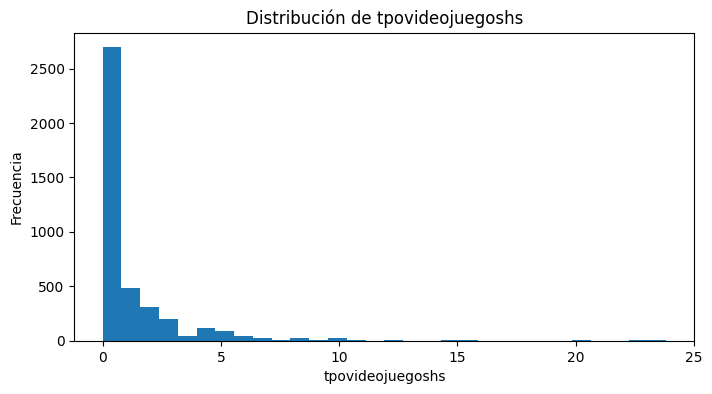

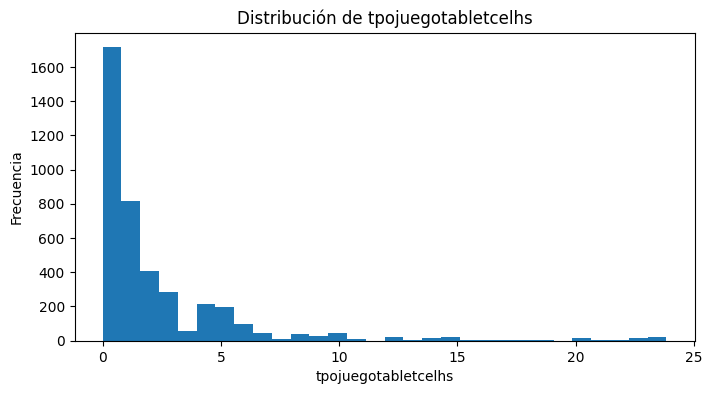

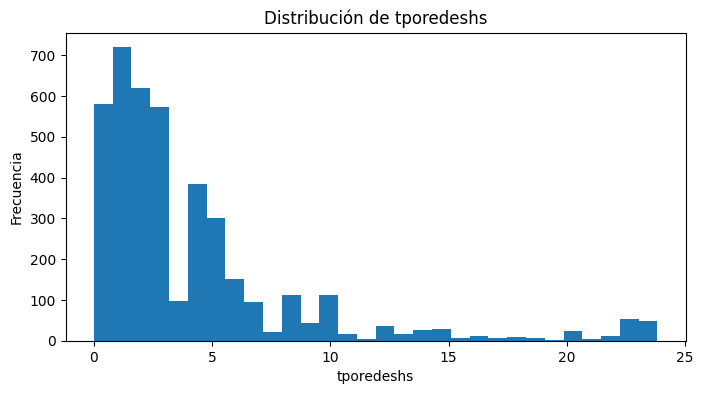

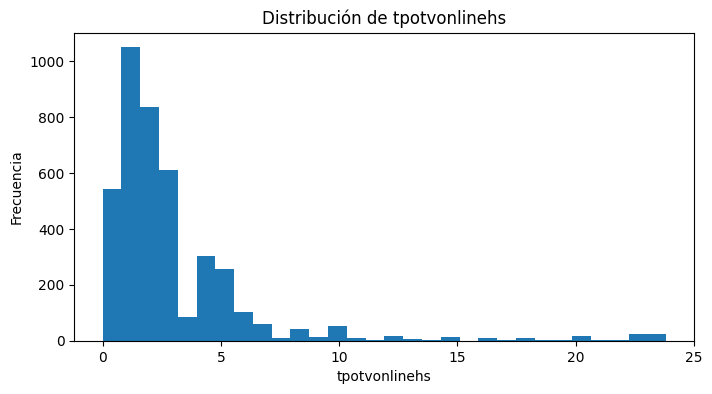

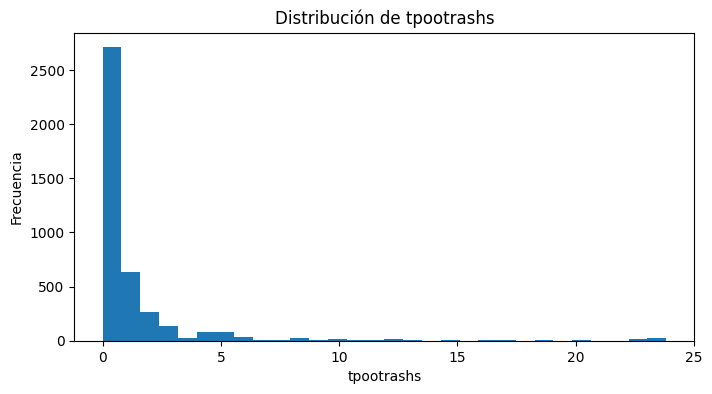

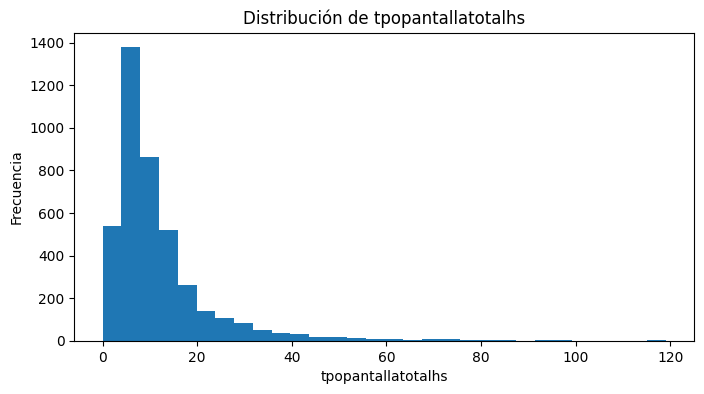

In [20]:
# Histogramas de las principales variables originales de consumo
for c in vars_consumo_original:
    serie = pd.to_numeric(df[c], errors="coerce")
    plt.figure(figsize=(8, 4))
    plt.hist(serie.dropna(), bins=30)
    plt.title(f"Distribución de {c}")
    plt.xlabel(c)
    plt.ylabel("Frecuencia")
    plt.show()

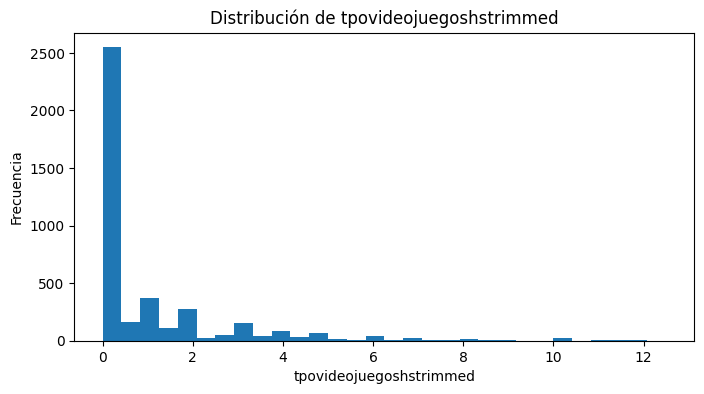

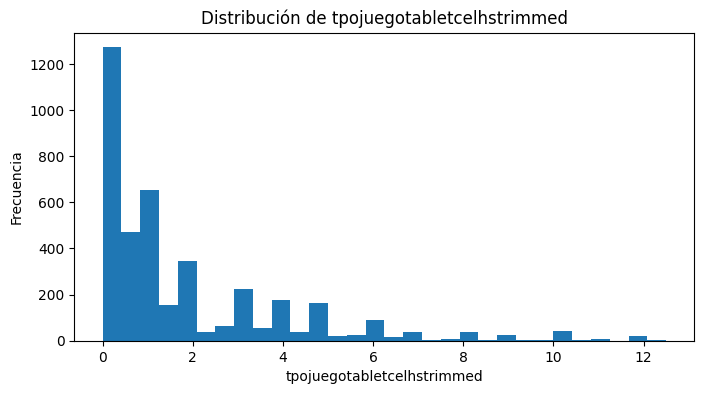

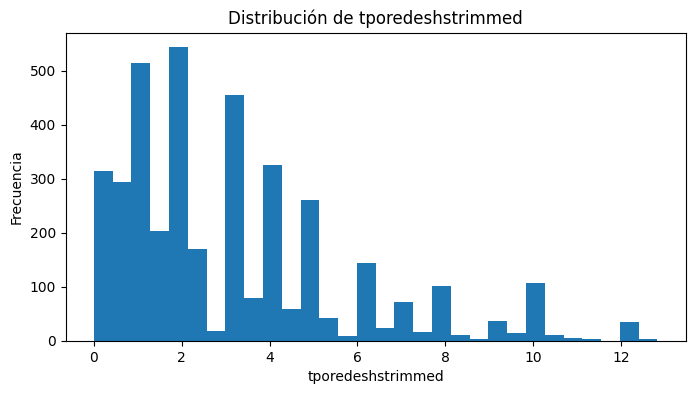

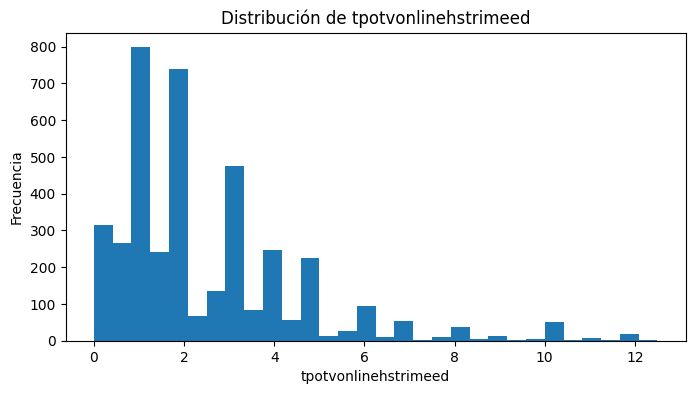

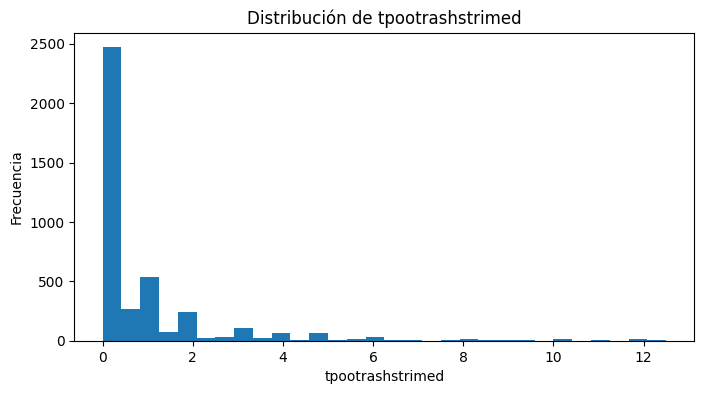

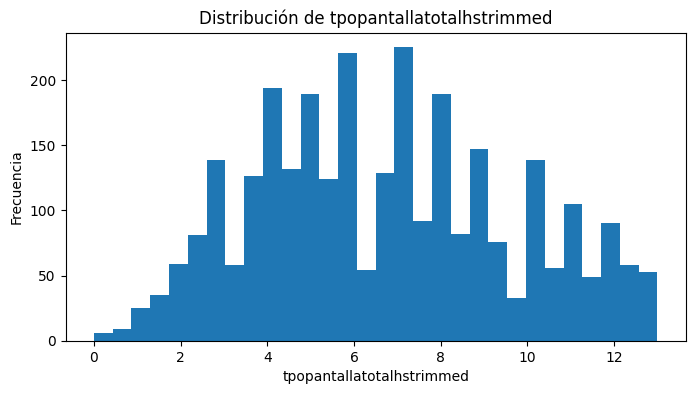

In [21]:
# Histogramas de las principales variables trimmed de consumo
for c in vars_consumo_trimmed:
    serie = pd.to_numeric(df[c], errors="coerce")
    plt.figure(figsize=(8, 4))
    plt.hist(serie.dropna(), bins=30)
    plt.title(f"Distribución de {c}")
    plt.xlabel(c)
    plt.ylabel("Frecuencia")
    plt.show()

**Interpretación:**

Las variables originales de consumo digital presentan distribuciones asimétricas y valores extremos elevados. Esta situación se observa tanto en las estadísticas descriptivas como en los histogramas. Las versiones trimmed presentan rangos más acotados y reducen la influencia de los valores extremos, por lo que resultan más adecuadas para representar la intensidad de consumo digital en las etapas posteriores del análisis. En consecuencia, para la construcción de los clusters se priorizarán las versiones trimmed de estas variables.

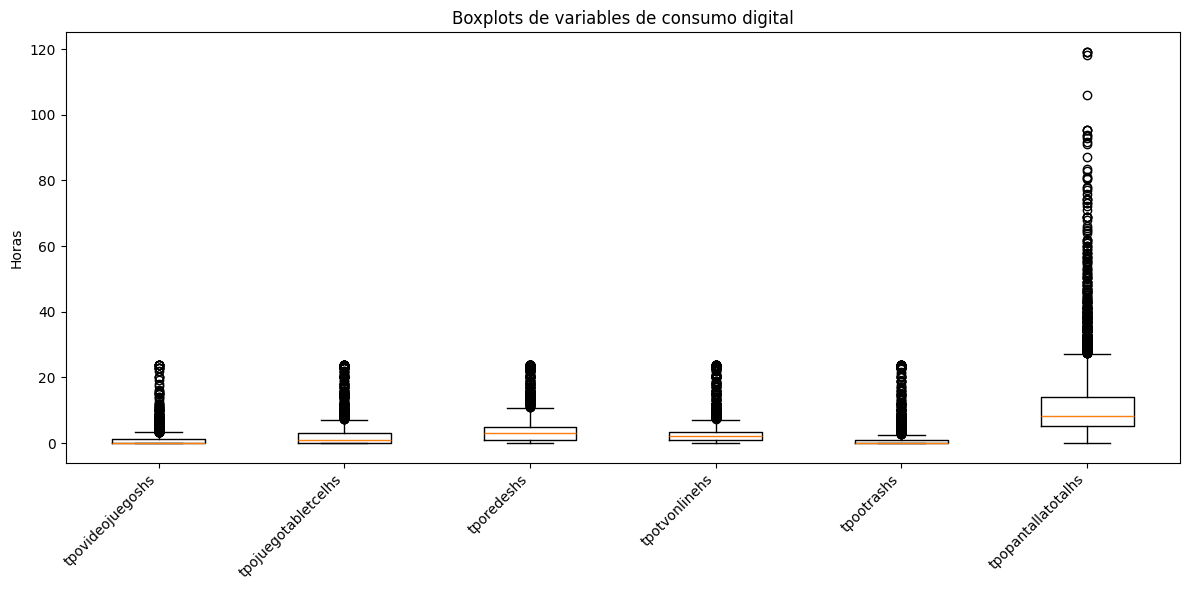

In [22]:
# Boxplots de consumo digital original
if vars_consumo_original:
    datos_plot = df[vars_consumo_original].apply(pd.to_numeric, errors="coerce")
    plt.figure(figsize=(12, 6))
    plt.boxplot(
        [datos_plot[c].dropna() for c in vars_consumo_original],
        tick_labels=vars_consumo_original,
        showfliers=True
    )
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Horas")
    plt.title("Boxplots de variables de consumo digital")
    plt.tight_layout()
    plt.show()

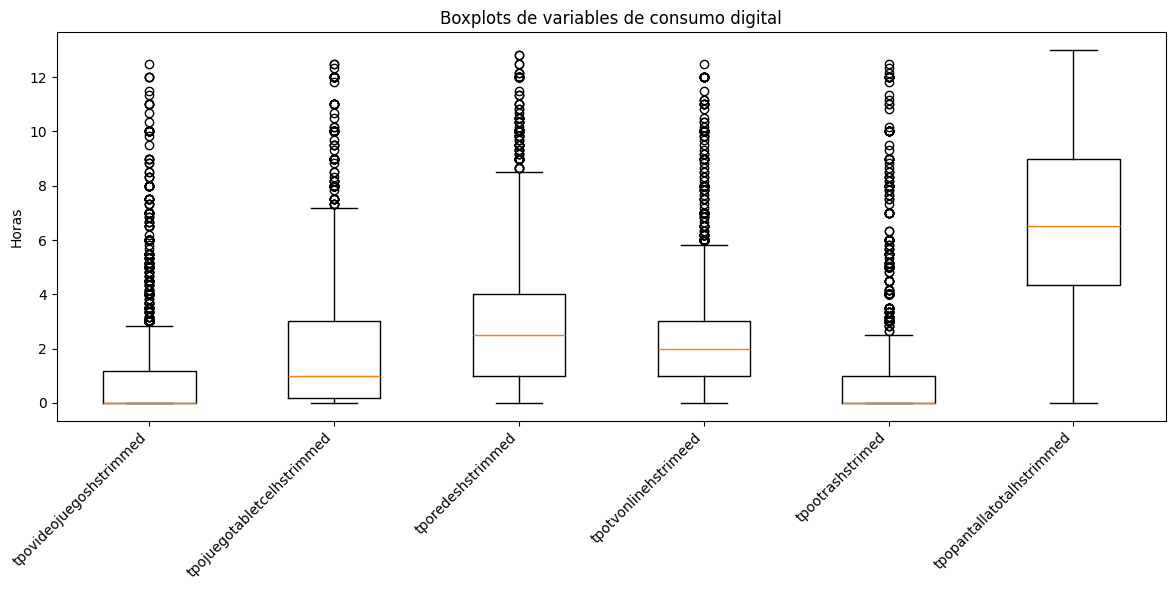

In [23]:
# Boxplots de consumo digital trimmed
if vars_consumo_trimmed:
    datos_plot = df[vars_consumo_trimmed].apply(pd.to_numeric, errors="coerce")
    plt.figure(figsize=(12, 6))
    plt.boxplot(
        [datos_plot[c].dropna() for c in vars_consumo_trimmed],
        tick_labels=vars_consumo_trimmed,
        showfliers=True
    )
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Horas")
    plt.title("Boxplots de variables de consumo digital")
    plt.tight_layout()
    plt.show()

**Conclusión:**

Luego del análisis comparativo de las variables de consumo digital originales y sus versiones trimmed, se observaron diferencias relevantes en su distribución, dispersión y presencia de valores extremos. Las variables trimmed presentan rangos más acotados y una menor influencia de valores extremos, por lo que se consideran más adecuadas para representar los patrones de consumo digital. En consecuencia, se priorizarán estas versiones para las etapas posteriores del análisis y para la construcción de los clusters, excluyendo del conjunto de variables seleccionadas sus correspondientes versiones originales.

## 7.3 Validación del tiempo total de pantalla

Se comprobará si el tiempo total de pantalla coincide con la suma de sus componentes. Esta validación permite detectar inconsistencias y decidir si conviene utilizar el total provisto, reconstruirlo o trabajar directamente con los componentes.

In [24]:
componentes = [
    "tpovideojuegoshs",
    "tpojuegotabletcelhs",
    "tporedeshs",
    "tpotvonlinehs",
    "tpootrashs",
]
componentes = [c for c in componentes if c in df.columns]

if "tpopantallatotalhs" in df.columns and len(componentes) >= 2:
    suma_componentes = df[componentes].sum(axis=1, min_count=len(componentes))
    diferencia = df["tpopantallatotalhs"] - suma_componentes

    validacion_total = pd.DataFrame({
        "total_reportado": df["tpopantallatotalhs"],
        "suma_componentes": suma_componentes,
        "diferencia": diferencia
    })

    tolerancia = 0.05

    print("Resumen de la diferencia total - suma de componentes:")
    display(diferencia.describe(percentiles=[.01, .05, .5, .95, .99]).to_frame())

    consistentes = diferencia.abs() <= tolerancia
    n_validos = diferencia.notna().sum()
    n_consistentes = consistentes.sum()

    if n_validos:
        print(f"Registros comparables: {n_validos}")
        print(f"Consistentes dentro de ±{tolerancia}: {n_consistentes} ({n_consistentes/n_validos*100:.2f}%)")

    print("\nCasos con mayores discrepancias:")
    display(validacion_total.loc[diferencia.abs().sort_values(ascending=False).head(15).index])

Resumen de la diferencia total - suma de componentes:


,0
count,4115.0
mean,0.0
std,0.0
min,0.0
1%,0.0
5%,0.0
50%,0.0
95%,0.0
99%,0.0
max,0.0


Registros comparables: 4115
Consistentes dentro de ±0.05: 4115 (100.00%)

Casos con mayores discrepancias:


,total_reportado,suma_componentes,diferencia
4114,8.833333,8.833333,0.0
0,11.000000,11.000000,0.0
1,10.500000,10.500000,0.0
4098,5.666667,5.666667,0.0
4097,15.500000,15.500000,0.0
4096,4.000000,4.000000,0.0
4095,6.000000,6.000000,0.0
4094,5.666667,5.666667,0.0
4093,4.500000,4.500000,0.0
4092,2.500000,2.500000,0.0


**Interpretación:**

La validación muestra que, para los 4.115 registros analizados, el tiempo total de pantalla coincide exactamente con la suma de sus componentes, obteniéndose una consistencia del 100 %. Por lo tanto, la variable de tiempo total de pantalla representa información agregada que ya se encuentra contenida en las variables específicas de consumo digital. Para la construcción de los clusters se priorizarán los componentes individuales, ya que permiten conservar información sobre la composición del consumo y evitar incorporar simultáneamente una variable total junto con las variables que la conforman.

## 7.4 Composición porcentual del consumo digital

In [25]:
vars_porcentajes = [
    "tpovideojuegosPORC",
    "tpotabletPORC",
    "tporedesPORC",
    "tpotvonlinePORC",
    "tpootrasPORC",
]
vars_porcentajes = [c for c in vars_porcentajes if c in df.columns]

if vars_porcentajes:
    display(resumen_numerico(df, vars_porcentajes))

    suma_porc = df[vars_porcentajes].sum(axis=1, min_count=len(vars_porcentajes))
    print("\nResumen de la suma de porcentajes:")
    display(suma_porc.describe(percentiles=[.01, .05, .5, .95, .99]).to_frame())

    problemas_porc = pd.DataFrame({
        "suma_porcentajes": suma_porc,
        "menor_que_99": suma_porc < 99,
        "mayor_que_101": suma_porc > 101,
    })

    print("Cantidad con suma < 99:", problemas_porc["menor_que_99"].sum())
    print("Cantidad con suma > 101:", problemas_porc["mayor_que_101"].sum())

    for c in vars_porcentajes:
        print(
            f"{c}: negativos={(df[c] < 0).sum()}, "
            f">100={(df[c] > 100).sum()}, "
            f"missing={df[c].isna().sum()}"
        )

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
tpovideojuegosPORC,2969.0,9.374958,16.114084,0.0,0.0,0.000000,0.000000,0.000000,15.254237,45.953177,66.666664,89.189188
tpotabletPORC,2969.0,17.604126,17.653831,0.0,0.0,0.000000,0.000000,13.043476,28.571427,50.000000,67.047622,100.000000
tporedesPORC,2969.0,36.675647,22.428659,0.0,0.0,2.873705,19.999998,33.333334,50.000000,77.777776,94.897243,100.000000
tpotvonlinePORC,2969.0,29.400741,18.280185,0.0,0.0,0.000000,16.666664,27.272727,40.000000,62.500000,80.000002,100.000000
tpootrasPORC,2969.0,6.944527,12.242976,0.0,0.0,0.000000,0.000000,0.000000,10.526316,32.851027,53.721212,100.000000



Resumen de la suma de porcentajes:


,0
count,2.969000e+03
mean,1.000000e+02
std,9.718136e-15
min,1.000000e+02
1%,1.000000e+02
5%,1.000000e+02
50%,1.000000e+02
95%,1.000000e+02
99%,1.000000e+02
max,1.000000e+02


Cantidad con suma < 99: 0
Cantidad con suma > 101: 0
tpovideojuegosPORC: negativos=0, >100=0, missing=1146
tpotabletPORC: negativos=0, >100=0, missing=1146
tporedesPORC: negativos=0, >100=0, missing=1146
tpotvonlinePORC: negativos=0, >100=0, missing=1146
tpootrasPORC: negativos=0, >100=0, missing=1146


### Consideración metodológica sobre porcentajes

Las variables porcentuales representan la composición relativa del consumo digital según el tipo de actividad. En los 2.969 registros con información disponible, las cinco proporciones suman el 100 %, confirmando que existe una dependencia matemática entre ellas.
Si bien estas variables podrían resultar útiles para describir la composición del consumo, presentan 1.146 valores faltantes cada una y constituyen una representación derivada de las variables de intensidad. Para evitar incorporar información redundante en el clustering, se priorizarán las variables trimmed de intensidad y las variables porcentuales serán excluidas del conjunto de variables seleccionado para la formación de los clusters.

## 7.5 Frecuencia de uso de dispositivos

In [26]:
vars_dispositivos_raw = [
    "PC o Laptop", "Teléfono celular 2", "Tablet",
    "Consola de juegos", "TV o Smart TV"
]

vars_dispositivos_trimmed = [
    "cantdiascompustrimmed",
    "cantdiascelulartrimmed",
    "cantdiastablettrimmed",
    "cantdiasconsolajuegostrimmed",
    "cantdiastvtrimmed",
]

vars_dispositivos_bin = [
    "cantdiascompus01",
    "cantdiascelular01",
    "cantdiastablet01",
    "cantdiasconsolajuegos01",
    "cantdiastv01",
]

for grupo, columnas in {
    "Originales": vars_dispositivos_raw,
    "Tratadas": vars_dispositivos_trimmed,
    "Binarias": vars_dispositivos_bin
}.items():
    disponibles = [c for c in columnas if c in df.columns]
    print(f"\n{grupo}:")
    if disponibles:
        display(resumen_numerico(df, disponibles))


Originales:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
PC o Laptop,4115.0,0.915674,1.792854,0.0,0.0,0.0,0.0,0.0,1.0,5.0,7.0,9.0
Teléfono celular 2,4115.0,5.948967,2.126601,0.0,0.0,1.0,5.0,7.0,7.0,8.0,9.0,9.0
Tablet,4115.0,0.379830,1.295380,0.0,0.0,0.0,0.0,0.0,0.0,3.0,7.0,9.0
Consola de juegos,4115.0,0.754800,1.693994,0.0,0.0,0.0,0.0,0.0,0.0,5.0,7.0,9.0
TV o Smart TV,4115.0,2.715917,2.639262,0.0,0.0,0.0,0.0,2.0,5.0,7.0,9.0,9.0



Tratadas:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
cantdiascompustrimmed,4097.0,0.880644,1.716805,0.0,0.0,0.0,0.0,0.0,1.0,5.0,7.0,7.0
cantdiascelulartrimmed,3907.0,5.799335,2.076166,0.0,0.0,1.0,5.0,7.0,7.0,7.0,7.0,7.0
cantdiastablettrimmed,4105.0,0.359562,1.229836,0.0,0.0,0.0,0.0,0.0,0.0,3.0,7.0,7.0
cantdiasconsolajuegostrimmed,4089.0,0.704084,1.574623,0.0,0.0,0.0,0.0,0.0,0.0,5.0,7.0,7.0
cantdiastvtrimmed,4056.0,2.627959,2.554346,0.0,0.0,0.0,0.0,2.0,5.0,7.0,7.0,7.0



Binarias:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
cantdiascompus01,4115.0,0.312758,0.463673,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
cantdiascelular01,4115.0,0.971810,0.165534,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
cantdiastablet01,4115.0,0.116889,0.321328,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
cantdiasconsolajuegos01,4115.0,0.236695,0.425105,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
cantdiastv01,4115.0,0.683597,0.465129,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0


**Conclusión:**

La comparación entre las variables originales, trimmed y binarias muestra que las versiones trimmed conservan información sobre la frecuencia de uso de cada dispositivo, expresada en cantidad de días, al mismo tiempo que presentan un rango más acotado. En cambio, las variables binarias únicamente indican presencia o ausencia de uso, perdiendo información sobre su frecuencia. Por este motivo, para las etapas posteriores del análisis se priorizarán las variables trimmed de cantidad de días de uso y se excluirán sus correspondientes versiones originales y binarias del conjunto de variables utilizado para el clustering.

## 7.6 Uso de pantallas cerca del horario de dormir

In [27]:
# Tomamos como 0 = No y 1 = Sí

vars_bedtime = [
    "WATCHTVbedtime7D01",
    "COMPUbedtime1D01",
    "COMPUbedtime2D01",
]

vars_bedtime = [c for c in vars_bedtime if c in df.columns]

for c in vars_bedtime:
    print(f"\n{c}")
    display(df[c].value_counts(dropna=False).sort_index().rename("cantidad").to_frame())


WATCHTVbedtime7D01


,cantidad
WATCHTVbedtime7D01,
0,3453
1,662



COMPUbedtime1D01


,cantidad
COMPUbedtime1D01,
0,3704
1,411



COMPUbedtime2D01


,cantidad
COMPUbedtime2D01,
0,3792
1,323


**Interpretación:**

Las tres variables permiten identificar hábitos de uso de pantallas próximos al horario de dormir. Teniendo en consideracion los valores de 1 = usan las pantallas en horarios de dormir y 0 = que no usan pantallas en horarios de dormir. Por lo que se conservarán para la caracterización posterior de los perfiles obtenidos.

## 7.7 Sueño

In [28]:
vars_sueno = [
    "dursiestasemanahs",
    "¿Cuánto tiempo de pantalla (dispositivos electrónicos) utilizas antes de dormirte los días de semana?",
    "horacenahr",
    "horasueñosemanahr-proc",
    "horasueñosemanahr",
    "¿Cuánto tiempo en Minutos tardas en dormirte?",
    "horalevantarsesemanahr",
    "tposueñosem",
    "tposueñosemTRIMMED",
    "horaacostarfsemanahr",
    "horalevantarsefsemanahr-proc",
    "tpofsueñosem",
    "tposueñofsemTRIMMED",
    "difonsetsueño",
]
vars_sueno = [c for c in vars_sueno if c in df.columns]

display(resumen_numerico(df, vars_sueno))

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
dursiestasemanahs,4115.0,1.317375,2.102711,0.000000,0.000000e+00,0.000000,0.000000,0.166667,2.000000,5.000000,8.833333,23.833333
¿Cuánto tiempo de pantalla (dispositivos electrónicos) utilizas antes de dormirte los días de semana?,4115.0,1.146497,2.431514,0.000000,0.000000e+00,0.000000,0.000000,0.000000,1.500000,5.000000,11.930000,23.833333
horacenahr,3826.0,21.510716,0.937604,19.500000,1.950000e+01,20.500000,20.500000,21.500000,22.500000,23.500000,23.500000,24.500000
horasueñosemanahr-proc,3624.0,21.662804,3.288331,13.500000,1.350000e+01,13.500000,21.500000,22.500000,23.500000,24.500000,24.500000,24.500000
horasueñosemanahr,3624.0,23.477373,1.437457,19.500000,2.050000e+01,21.500000,22.500000,23.500000,23.500000,26.500000,27.500000,30.500000
¿Cuánto tiempo en Minutos tardas en dormirte?,4115.0,22.369016,36.071497,0.000000,1.000000e+00,3.000000,10.000000,15.000000,30.000000,60.000000,128.600000,999.000000
horalevantarsesemanahr,4115.0,6.710288,1.024273,0.000000,5.000000e+00,5.833333,6.333333,6.666667,7.000000,7.550000,10.500000,23.833333
tposueñosem,3624.0,6.851534,1.770053,-10.150000,1.500000e+00,3.833333,6.166667,7.000000,7.833333,8.950000,10.730833,24.000000
tposueñosemTRIMMED,3411.0,7.057864,1.230224,4.000000,4.166667e+00,4.833333,6.333333,7.083333,7.833333,8.916667,10.166667,11.883333
horaacostarfsemanahr,4115.0,25.469907,2.253659,19.000000,1.916667e+01,22.000000,23.833333,25.500000,27.000000,29.500000,30.310000,30.833333


In [29]:
# Comparar variables de duración de sueño originales y trimmed
pares_trimmed_sueno = [
    ("tposueñosem", "tposueñosemTRIMMED"),
    ("tpofsueñosem", "tposueñofsemTRIMMED"),
]

for original, trimmed in pares_trimmed_sueno:
    if original in df.columns and trimmed in df.columns:
        print(f"\n{original} vs {trimmed}")
        comparacion = pd.DataFrame({
            original: df[original],
            trimmed: df[trimmed],
        })
        print("Original:")
        display(df[original].describe(percentiles=[.01,.05,.5,.95,.99]).to_frame())
        print("Trimmed:")
        display(df[trimmed].describe(percentiles=[.01,.05,.5,.95,.99]).to_frame())
        print("Registros donde trimmed es NaN pero original no:",
              (df[trimmed].isna() & df[original].notna()).sum())


tposueñosem vs tposueñosemTRIMMED
Original:


,tposueñosem
count,3624.000000
mean,6.851534
std,1.770053
min,-10.150000
1%,1.500000
5%,3.833333
50%,7.000000
95%,8.950000
99%,10.730833
max,24.000000


Trimmed:


,tposueñosemTRIMMED
count,3411.000000
mean,7.057864
std,1.230224
min,4.000000
1%,4.166667
5%,4.833333
50%,7.083333
95%,8.916667
99%,10.166667
max,11.883333


Registros donde trimmed es NaN pero original no: 213

tpofsueñosem vs tposueñofsemTRIMMED
Original:


,tpofsueñosem
count,4115.000000
mean,9.176063
std,3.136769
min,-5.333333
1%,-2.500000
5%,4.783333
50%,9.333333
95%,13.000000
99%,18.000000
max,24.000000


Trimmed:


,tposueñofsemTRIMMED
count,3864.000000
mean,9.291667
std,2.011884
min,1.000000
1%,3.876667
5%,6.000000
50%,9.500000
95%,12.500000
99%,13.500000
max,14.000000


Registros donde trimmed es NaN pero original no: 251


**Interpretación:**

El análisis de las variables de sueño muestra diferencias importantes entre las versiones originales y sus correspondientes versiones TRIMMED. En las variables originales de duración del sueño se observan valores extremos e incluso valores negativos, que no resultan coherentes con una duración real de descanso. Las versiones TRIMMED presentan rangos más acotados y plausibles, aunque contienen una mayor cantidad de valores faltantes debido al tratamiento aplicado durante el procesamiento original.
Por este motivo, para la caracterización posterior de los clusters se priorizarán las versiones TRIMMED de la duración del sueño, evitando utilizar simultáneamente las variables originales y tratadas para no incorporar información redundante. Estas variables de sueño no se utilizarán para formar los clusters, sino para analizar posteriormente si los perfiles de consumo digital obtenidos presentan diferencias en sus patrones de descanso.

## 7.8 Somnolencia / PDSS

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Resultado,4115.0,18.653220,5.172807,2.0,7.0,10.0,15.0,19.0,22.0,27.0,29.0,32.0
somno01pdss,4115.0,0.719320,0.449386,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
problemasatencionrecod,4115.0,2.173269,1.044403,0.0,0.0,0.0,1.0,2.0,3.0,4.0,4.0,4.0
¿Con qué frecuencia te quedás dormido/a o te da sueño mientras hacés la tarea?,4115.0,1.406561,1.251817,0.0,0.0,0.0,0.0,1.0,2.0,4.0,4.0,4.0
¿Estás atento/a o alerta en clase?,4115.0,3.019927,0.843397,0.0,0.0,1.0,3.0,3.0,4.0,4.0,4.0,4.0
¿Con qué frecuencia te sentís cansado y de mal humor durante el día?,4115.0,2.147995,1.084302,0.0,0.0,0.0,1.0,2.0,3.0,4.0,4.0,4.0
¿Te cuesta levantarte de la cama a la mañana?,4115.0,2.906197,1.280894,0.0,0.0,0.0,2.0,3.0,4.0,4.0,4.0,4.0
¿Te volvés a quedar dormido/a después de que te despertaron a la mañana?,4115.0,1.807776,1.471736,0.0,0.0,0.0,0.0,2.0,3.0,4.0,4.0,4.0
¿Necesitás que alguien te despierte por la mañana?,4115.0,2.324423,1.680907,0.0,0.0,0.0,0.0,3.0,4.0,4.0,4.0,4.0
¿Con qué frecuencia sentís que necesitás dormir más tiempo?,4115.0,2.867072,1.116270,0.0,0.0,1.0,2.0,3.0,4.0,4.0,4.0,4.0


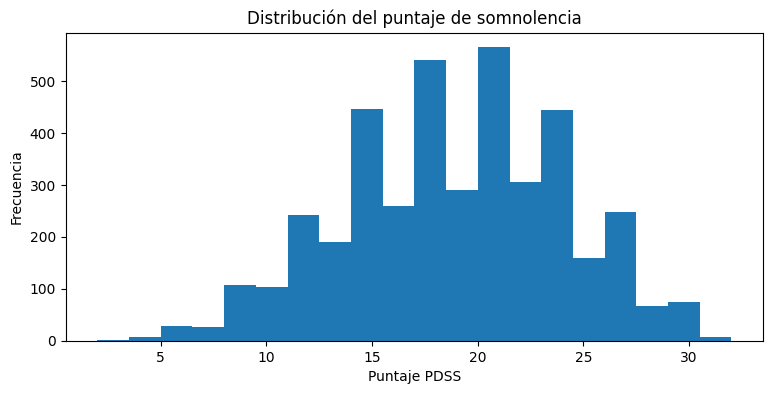

PDSS según indicador binario:


,count,mean,std,min,25%,50%,75%,max
somno01pdss,,,,,,,,
0,1155.0,12.234632,2.528420,2.0,11.0,13.0,14.0,15.0
1,2960.0,21.157770,3.514722,16.0,18.0,21.0,24.0,32.0


In [30]:
vars_pdss = [
    "Resultado",
    "somno01pdss",
    "problemasatencionrecod",
    "¿Con qué frecuencia te quedás dormido/a o te da sueño mientras hacés la tarea?",
    "¿Estás atento/a o alerta en clase?",
    "¿Con qué frecuencia te sentís cansado y de mal humor durante el día?",
    "¿Te cuesta levantarte de la cama a la mañana?",
    "¿Te volvés a quedar dormido/a después de que te despertaron a la mañana?",
    "¿Necesitás que alguien te despierte por la mañana?",
    "¿Con qué frecuencia sentís que necesitás dormir más tiempo?",
]
vars_pdss = [c for c in vars_pdss if c in df.columns]

display(resumen_numerico(df, vars_pdss))

if "Resultado" in df.columns:
    plt.figure(figsize=(9, 4))
    plt.hist(df["Resultado"].dropna(), bins=20)
    plt.xlabel("Puntaje PDSS")
    plt.ylabel("Frecuencia")
    plt.title("Distribución del puntaje de somnolencia")
    plt.show()

if "Resultado" in df.columns and "somno01pdss" in df.columns:
    print("PDSS según indicador binario:")
    display(df.groupby("somno01pdss")["Resultado"].describe())

**Interpretación:**

El puntaje de somnolencia (Resultado) presenta valores entre 2 y 32 puntos, con una mediana de 19. El indicador binario somno01pdss divide los registros en dos grupos claramente diferenciados: los casos con valor 0 presentan puntajes de hasta 15, mientras que los casos con valor 1 presentan puntajes desde 16 en adelante. Esto indica que somno01pdss corresponde a una recodificación del puntaje PDSS utilizando un punto de corte entre ambos valores.


En el dataset, aproximadamente el 71,9 % de los registros pertenece a la categoría somno01pdss = 1, mientras que el 28,1 % corresponde a la categoría 0. Estas variables no se utilizarán para construir los clusters, ya que el agrupamiento estará basado en los patrones de consumo digital. Se conservarán para la caracterización posterior de los grupos, permitiendo analizar si los perfiles identificados presentan diferencias en sus niveles de somnolencia diurna.

## 7.9 Rendimiento académico

In [31]:
vars_academicas = [
    "lengua", "matematica", "prom", "aplazos", "missingnotas"
]
vars_academicas = [c for c in vars_academicas if c in df.columns]

display(resumen_numerico(df, vars_academicas))

for c in vars_academicas:
    print(f"{c}: missing = {df[c].isna().sum()} ({df[c].isna().mean()*100:.2f}%)")

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
lengua,1261.0,7.439453,1.457938,1.0,4.0,5.0,6.66,8.0,8.5,10.0,10.00,10.0
matematica,1257.0,7.175123,1.804322,1.0,2.0,4.0,6.00,7.0,9.0,10.0,10.00,10.0
prom,1257.0,7.308385,1.440699,2.0,3.5,4.5,6.50,7.5,8.5,9.5,9.72,10.0
aplazos,1257.0,0.430390,0.495328,0.0,0.0,0.0,0.00,0.0,1.0,1.0,1.00,1.0
missingnotas,4115.0,0.694532,0.460661,0.0,0.0,0.0,0.00,1.0,1.0,1.0,1.00,1.0


lengua: missing = 2854 (69.36%)
matematica: missing = 2858 (69.45%)
prom: missing = 2858 (69.45%)
aplazos: missing = 2858 (69.45%)
missingnotas: missing = 0 (0.00%)


### Interpretación metodológica del rendimiento académico

Las variables académicas se consideran variables de caracterización y no variables principales para formar los clusters de consumo digital. Dado que aproximadamente el 69 % de los registros no dispone de calificaciones académicas, su ausencia no debería excluir automáticamente a un adolescente del clustering si cuenta con información suficiente sobre comportamiento digital. Estas variables podrán utilizarse posteriormente para explorar posibles diferencias de rendimiento académico entre los perfiles obtenidos, considerando la disponibilidad limitada de información.

# 8 Detección de valores extremos

Un valor extremo estadístico no es necesariamente un error. Se utilizará el método IQR como herramienta de diagnóstico, pero las decisiones se tomarán considerando también la semántica de cada variable.

In [32]:
def detectar_outliers_iqr(dataframe, columnas):
    filas = []

    for c in columnas:
        if c not in dataframe.columns:
            continue

        s = pd.to_numeric(dataframe[c], errors="coerce").dropna()
        if s.empty:
            continue

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1

        limite_inf = q1 - 1.5 * iqr
        limite_sup = q3 + 1.5 * iqr

        mask = (s < limite_inf) | (s > limite_sup)

        filas.append({
            "variable": c,
            "min": s.min(),
            "q1": q1,
            "mediana": s.median(),
            "q3": q3,
            "max": s.max(),
            "limite_inferior_iqr": limite_inf,
            "limite_superior_iqr": limite_sup,
            "cantidad_outliers_iqr": int(mask.sum()),
            "porcentaje_outliers_iqr": mask.mean() * 100,
        })

    return pd.DataFrame(filas)

vars_outliers = list(dict.fromkeys(
    vars_consumo_original
    + vars_sueno
    + ["tpoviajemin", "Altura en m", "Peso en kg", "imc"]
))

tabla_outliers = detectar_outliers_iqr(df, vars_outliers)

display(
    tabla_outliers.sort_values(
        "porcentaje_outliers_iqr", ascending=False
    ).reset_index(drop=True)
)

,variable,min,q1,mediana,q3,max,limite_inferior_iqr,limite_superior_iqr,cantidad_outliers_iqr,porcentaje_outliers_iqr
0,horasueñosemanahr,19.500000,22.500000,23.500000,23.500000,30.500000,21.000000,25.000000,594,16.390728
1,horasueñosemanahr-proc,13.500000,21.500000,22.500000,23.500000,24.500000,18.500000,26.500000,540,14.900662
2,difonsetsueño,0.000000,1.000000,2.500000,4.500000,17.166667,-4.250000,9.750000,487,13.438190
3,tpoviajemin,0.000000,10.000000,15.000000,30.000000,5400.000000,-20.000000,60.000000,495,12.029162
4,tpootrashs,0.000000,0.000000,0.000000,1.000000,23.833333,-1.500000,2.500000,483,11.737546
5,tpovideojuegoshs,0.000000,0.000000,0.000000,1.333333,23.833333,-2.000000,3.333334,418,10.157959
6,¿Cuánto tiempo de pantalla (dispositivos elect...,0.000000,0.000000,0.000000,1.500000,23.833333,-2.250000,3.750000,385,9.356015
7,tpopantallatotalhs,0.000000,5.166667,8.166666,14.000000,119.166667,-8.083333,27.250000,314,7.630620
8,tporedeshs,0.000000,1.000000,3.000000,5.000000,23.833333,-5.000000,11.000000,293,7.120292
9,tpojuegotabletcelhs,0.000000,0.166667,1.000000,3.000000,23.833333,-4.083334,7.250000,273,6.634265


**Conclusión:**

La aplicación del método IQR permitió identificar valores estadísticamente extremos en distintas variables del dataset. Sin embargo, estos casos no serán eliminados automáticamente, ya que un valor extremo no necesariamente representa un error y su interpretación depende de la naturaleza de cada variable.

El análisis permitió detectar algunos valores claramente inconsistentes o poco plausibles en las variables originales, como duraciones negativas de sueño y valores excepcionalmente elevados en tiempo de viaje o latencia para conciliar el sueño. Asimismo, las versiones TRIMMED presentan rangos más acotados y una menor proporción de valores extremos, lo que respalda su utilización en las etapas posteriores cuando estén disponibles.

Para las variables utilizadas en la formación de los clusters, los valores extremos serán evaluados considerando tanto su distribución estadística como su significado. Esto resulta especialmente importante debido a que K-Means se basa en distancias y puede verse afectado por observaciones extremas.

# 9 Relaciones entre variables y redundancia


In [33]:
# Correlación de variables numéricas relevantes
vars_corr = list(dict.fromkeys(
    vars_consumo_original
    + vars_consumo_trimmed
    + vars_porcentajes
    + vars_dispositivos_trimmed
    + ["edad", "Resultado", "tposueñosemTRIMMED", "tposueñofsemTRIMMED"]
))
vars_corr = [c for c in vars_corr if c in df.columns]

corr = df[vars_corr].corr(numeric_only=True)

# Mostrar correlaciones absolutas altas excluyendo diagonal
pares_corr = []
for i, c1 in enumerate(corr.columns):
    for j, c2 in enumerate(corr.columns):
        if j <= i:
            continue
        valor = corr.loc[c1, c2]
        if pd.notna(valor) and abs(valor) >= 0.90:
            pares_corr.append({
                "variable_1": c1,
                "variable_2": c2,
                "correlacion": valor
            })

pares_corr_df = pd.DataFrame(pares_corr)

if len(pares_corr_df):
    display(
        pares_corr_df.assign(
            abs_corr=lambda x: x["correlacion"].abs()
        ).sort_values("abs_corr", ascending=False).drop(columns="abs_corr")
    )
else:
    print("No se encontraron pares con |r| >= 0.90 entre las variables seleccionadas.")

,variable_1,variable_2,correlacion
0,tpovideojuegoshs,tpovideojuegoshstrimmed,1.000000
2,tpojuegotabletcelhs,tpojuegotabletcelhstrimmed,1.000000
3,tporedeshs,tporedeshstrimmed,1.000000
4,tpotvonlinehs,tpotvonlinehstrimeed,1.000000
6,tpopantallatotalhs,tpopantallatotalhstrimmed,1.000000
5,tpootrashs,tpootrashstrimed,1.000000
1,tpovideojuegoshs,tpovideojuegosPORC,0.902829
7,tpovideojuegoshstrimmed,tpovideojuegosPORC,0.902829


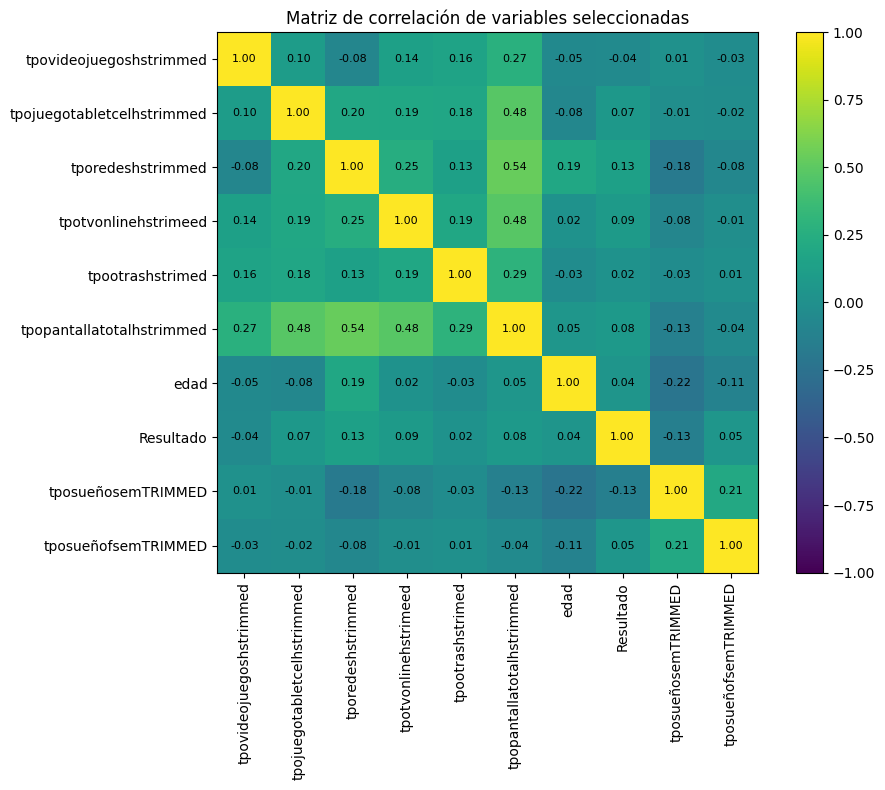

In [34]:
# Heatmap con matplotlib, limitado a un subconjunto para mantener legibilidad
corr_plot_cols = [
    c for c in [
        "tpovideojuegoshstrimmed",
        "tpojuegotabletcelhstrimmed",
        "tporedeshstrimmed",
        "tpotvonlinehstrimeed",
        "tpootrashstrimed",
        "tpopantallatotalhstrimmed",
        "edad",
        "Resultado",
        "tposueñosemTRIMMED",
        "tposueñofsemTRIMMED",
    ] if c in df.columns
]

if len(corr_plot_cols) >= 2:
    matriz = df[corr_plot_cols].corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(matriz, vmin=-1, vmax=1)

    ax.set_xticks(range(len(matriz.columns)))
    ax.set_xticklabels(matriz.columns, rotation=90)
    ax.set_yticks(range(len(matriz.columns)))
    ax.set_yticklabels(matriz.columns)

    for i in range(len(matriz.columns)):
        for j in range(len(matriz.columns)):
            ax.text(j, i, f"{matriz.iloc[i, j]:.2f}",
                    ha="center", va="center", fontsize=8)

    ax.set_title("Matriz de correlación de variables seleccionadas")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

**Interpretación y conclusión:**

El análisis de correlaciones permitió identificar una alta redundancia entre las variables originales de consumo digital y sus correspondientes versiones trimmed, alcanzando correlaciones de 1.00. Este resultado respalda la decisión de conservar una única representación de cada variable, priorizando las versiones trimmed seleccionadas previamente.

Entre las variables de consumo digital utilizadas para el análisis se observan, en general, correlaciones bajas a moderadas. El tiempo total de pantalla presenta asociaciones mayores con algunos de sus componentes, lo cual resulta esperable debido a que se construye a partir de ellos.

Por lo tanto, antes de construir los clusters se evitará incorporar simultáneamente variables que representen la misma información. La selección final buscará reducir redundancias y permitir que cada dimensión utilizada aporte información diferenciada sobre los patrones de consumo digital.

# 10 Agrupación conceptual de variables para limpieza y análisis

Para evitar mezclar funciones, se organizan las variables en grupos conceptuales.

In [35]:
variables_identificacion = [
    c for c in [
        "Submission ID", "Código"
    ] if c in df.columns
]

variables_intensidad = [
    c for c in [
        "tpovideojuegoshstrimmed",
        "tpojuegotabletcelhstrimmed",
        "tporedeshstrimmed",
        "tpotvonlinehstrimeed",
        "tpootrashstrimed",
    ] if c in df.columns
]

variables_dispositivos = [
    c for c in [
        "cantdiascompustrimmed",
        "cantdiascelulartrimmed",
        "cantdiastablettrimmed",
        "cantdiasconsolajuegostrimmed",
        "cantdiastvtrimmed",
    ] if c in df.columns
]

variables_contexto = [
    c for c in [
        "WATCHTVbedtime7D01",
        "COMPUbedtime1D01",
        "COMPUbedtime2D01",
    ] if c in df.columns
]

variables_caracterizacion_demografica = [
    c for c in ["edad", "Sexo", "sexonum", "grado", "Colegio", "Ciudad"]
    if c in df.columns
]

variables_caracterizacion_sueno = [
    c for c in [
        "tposueñosemTRIMMED",
        "tposueñofsemTRIMMED",
        "dursiestasemanahs",
        "difonsetsueño",
        "¿Cuánto tiempo en Minutos tardas en dormirte?",
    ] if c in df.columns
]

variables_caracterizacion_somnolencia = [
    c for c in ["Resultado", "somno01pdss"]
    if c in df.columns
]

variables_caracterizacion_academica = [
    c for c in ["lengua", "matematica", "prom", "aplazos"]
    if c in df.columns
]

grupos_variables = {
    "identificacion": variables_identificacion,
    "cluster_intensidad": variables_intensidad,
    "cluster_dispositivos": variables_dispositivos,
    "cluster_contexto": variables_contexto,
    "caracterizacion_demografica": variables_caracterizacion_demografica,
    "caracterizacion_sueno": variables_caracterizacion_sueno,
    "caracterizacion_somnolencia": variables_caracterizacion_somnolencia,
    "caracterizacion_academica": variables_caracterizacion_academica,
}

for nombre, lista in grupos_variables.items():
    print(f"\n{nombre}: {len(lista)} variables")
    for c in lista:
        print(" -", c)


identificacion: 2 variables
 - Submission ID
 - Código

cluster_intensidad: 5 variables
 - tpovideojuegoshstrimmed
 - tpojuegotabletcelhstrimmed
 - tporedeshstrimmed
 - tpotvonlinehstrimeed
 - tpootrashstrimed

cluster_dispositivos: 5 variables
 - cantdiascompustrimmed
 - cantdiascelulartrimmed
 - cantdiastablettrimmed
 - cantdiasconsolajuegostrimmed
 - cantdiastvtrimmed

cluster_contexto: 3 variables
 - WATCHTVbedtime7D01
 - COMPUbedtime1D01
 - COMPUbedtime2D01

caracterizacion_demografica: 6 variables
 - edad
 - Sexo
 - sexonum
 - grado
 - Colegio
 - Ciudad

caracterizacion_sueno: 5 variables
 - tposueñosemTRIMMED
 - tposueñofsemTRIMMED
 - dursiestasemanahs
 - difonsetsueño
 - ¿Cuánto tiempo en Minutos tardas en dormirte?

caracterizacion_somnolencia: 2 variables
 - Resultado
 - somno01pdss

caracterizacion_academica: 4 variables
 - lengua
 - matematica
 - prom
 - aplazos


### Selección de variables para limpieza y preprocesamiento:

A partir del análisis exploratorio realizado, las variables se organizaron según la función que podrán cumplir en las etapas posteriores. Las variables de intensidad de consumo, frecuencia de uso de dispositivos y contexto de uso se consideran candidatas para la construcción de los clusters, mientras que las variables demográficas, de sueño, somnolencia y rendimiento académico se conservarán principalmente para caracterizar e interpretar posteriormente los perfiles obtenidos.

Los identificadores administrativos, las variables redundantes y las distintas versiones de una misma característica serán evaluados en la etapa de limpieza para conservar únicamente las representaciones seleccionadas. Esta organización permitirá reducir la dimensionalidad y trabajar con un conjunto de datos más consistente, interpretable y alineado con el posterior análisis de clustering.

# 11 Limpieza y preprocesamiento

In [36]:
# Selección de variables relevantes para la segmentación
# y posterior caracterización de los clusters
df_limpio = df.copy()

df_limpio = df_limpio[
    variables_identificacion +
    variables_intensidad +
    variables_dispositivos +
    variables_contexto +
    variables_caracterizacion_demografica +
    variables_caracterizacion_sueno +
    variables_caracterizacion_somnolencia +
    variables_caracterizacion_academica
].copy()

In [37]:
print("Cant. Variables df_limpio",df_limpio.shape[1])

Cant. Variables df_limpio 32


In [38]:
df_limpio.columns

Index(['Submission ID', 'Código', 'tpovideojuegoshstrimmed',
       'tpojuegotabletcelhstrimmed', 'tporedeshstrimmed',
       'tpotvonlinehstrimeed', 'tpootrashstrimed', 'cantdiascompustrimmed',
       'cantdiascelulartrimmed', 'cantdiastablettrimmed',
       'cantdiasconsolajuegostrimmed', 'cantdiastvtrimmed',
       'WATCHTVbedtime7D01', 'COMPUbedtime1D01', 'COMPUbedtime2D01', 'edad',
       'Sexo', 'sexonum', 'grado', 'Colegio', 'Ciudad', 'tposueñosemTRIMMED',
       'tposueñofsemTRIMMED', 'dursiestasemanahs', 'difonsetsueño',
       '¿Cuánto tiempo en Minutos tardas en dormirte?', 'Resultado',
       'somno01pdss', 'lengua', 'matematica', 'prom', 'aplazos'],
      dtype='object')

In [39]:
# Filtramos los registros con edad informada al rango de 12 a 18 años.
# Los registros sin edad informada se conservan para no descartar casos
# que puedan contener información válida para la segmentación.

if "edad" in df_limpio.columns:
    fuera_rango = df_limpio["edad"].notna() & ~df_limpio["edad"].between(12, 18, inclusive="both")
    n_fuera = int(fuera_rango.sum())

    df_limpio = df_limpio.loc[~fuera_rango].copy()
else:
  print('NO')
print("Dimensiones luego de aplicar rango etario documentado:", df_limpio.shape)

Dimensiones luego de aplicar rango etario documentado: (4062, 32)


In [40]:
# Validación del filtro etario aplicado:
# verificamos la cantidad de registros resultantes, los valores faltantes
# y que las edades informadas se encuentren dentro del rango de 12 a 18 años.
print("Registros finales:", len(df_limpio))
print("Edad faltante:", df_limpio["edad"].isna().sum())
print("Edad mínima:", df_limpio["edad"].min())
print("Edad máxima:", df_limpio["edad"].max())

Registros finales: 4062
Edad faltante: 562
Edad mínima: 12.0
Edad máxima: 18.0


## Variables excluidas del df_limpio:

- WAZ
  - Nulos: 4088
  - % de nulos: 99,34 %
  - Motivo: se excluye por su altísimo porcentaje de datos faltantes.
- tpotvonlinePORC, tpotabletPORC, tporedesPORC, tpovideojuegosPORC, tpootrasPORC
  - Nulos: 1146 cada variable
  - % de nulos: 27,85 %
  - Motivo: son variables derivadas que expresan porcentajes de consumo y resultan redundantes respecto de las variables de intensidad seleccionadas.
- tpovideojuegoshs, tpojuegotabletcelhs, tporedeshs, tpotvonlinehs, tpootrashs
  - Motivo: corresponden a las versiones originales de las variables de intensidad. Se excluyen porque se conservaron sus respectivas versiones trimmed, utilizadas como representación tratada para el análisis.
- tpopantallatotalhs, tpopantallatotalhstrimmed
  - Motivo: representan una medida agregada del consumo total de pantallas. Se excluyen del conjunto seleccionado para evitar incorporar simultáneamente el total y sus componentes, reduciendo así la redundancia entre variables.
- cantdiascompus01, cantdiascelular01, cantdiastablet01, cantdiasconsolajuegos01, cantdiastv01
  - Motivo: son versiones binarias del uso de dispositivos. Se conservaron las variables trimmed de cantidad de días porque contienen mayor información sobre la frecuencia de uso.
- tposueñosem, tpofsueñosem
  - Motivo: corresponden a las versiones originales de duración del sueño. Se conservaron tposueñosemTRIMMED y tposueñofsemTRIMMED como versiones tratadas para la caracterización del sueño.

# 12 Descripción del dataset luego de la limpieza

In [41]:
n_original = len(df_original)
n_limpio = len(df_limpio)
n_vars_original = df_original.shape[1]
n_vars_limpio = df_limpio.shape[1]

display(Markdown(f'''
### Dataset resultante

- Registros originales: **{n_original:,}**
- Registros luego del filtro poblacional: **{n_limpio:,}**
- Variables originales: **{n_vars_original}**
- Variables conservadas en `df_limpio`: **{n_vars_limpio}**

Las variables demográficas, de sueño, somnolencia y rendimiento académico se conservan en df_limpio para la caracterización posterior de los clusters, pero no se utilizarán como variables de entrada para la formación de los grupos. De esta manera, los clusters se construirán a partir de los patrones de consumo digital y posteriormente podrán analizarse sus diferencias respecto de estas características externas.
'''))


### Dataset resultante

- Registros originales: **4,115**
- Registros luego del filtro poblacional: **4,062**
- Variables originales: **125**
- Variables conservadas en `df_limpio`: **32**

Las variables demográficas, de sueño, somnolencia y rendimiento académico se conservan en df_limpio para la caracterización posterior de los clusters, pero no se utilizarán como variables de entrada para la formación de los grupos. De esta manera, los clusters se construirán a partir de los patrones de consumo digital y posteriormente podrán analizarse sus diferencias respecto de estas características externas.


In [42]:
# Resumen de la estructura del dataset resultante
resumen_limpio = pd.DataFrame({
    "Tipo de dato": df_limpio.dtypes.astype(str),
    "Nulos": df_limpio.isna().sum(),
    "% Nulos": (df_limpio.isna().mean() * 100).round(2)
})

display(resumen_limpio)

,Tipo de dato,Nulos,% Nulos
Submission ID,int64,0,0.00
Código,object,0,0.00
tpovideojuegoshstrimmed,float64,29,0.71
tpojuegotabletcelhstrimmed,float64,110,2.71
tporedeshstrimmed,float64,241,5.93
tpotvonlinehstrimeed,float64,111,2.73
tpootrashstrimed,float64,64,1.58
cantdiascompustrimmed,float64,17,0.42
cantdiascelulartrimmed,float64,204,5.02
cantdiastablettrimmed,float64,9,0.22


**Conclusión:**

Luego del proceso de selección y filtrado, el dataset resultante contiene 4.062 registros y 32 variables relevantes para la segmentación y posterior caracterización de los perfiles. Las variables seleccionadas presentan distintos niveles de datos faltantes, por lo que su tratamiento deberá considerarse según el conjunto de variables utilizado en cada análisis. Las variables demográficas, de sueño, somnolencia y rendimiento académico se conservarán para caracterizar posteriormente los clusters, sin intervenir en su formación.

# 13 Exportación del dataset limpio

In [43]:
# Guardado del dataset resultante
df_limpio.to_csv("dataset_limpio.csv", index=False)
df_limpio.to_excel("dataset_limpio.xlsx", index=False)

print("Dataset limpio exportado correctamente.")
print("Dimensiones:", df_limpio.shape)

Dataset limpio exportado correctamente.
Dimensiones: (4062, 32)


In [45]:
# Descarga del dataset_limpio
files.download("dataset_limpio.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 14 Modelo de Aprendizaje Automático propuesto

El problema es de **aprendizaje automático no supervisado** porque no existe una etiqueta objetivo conocida que indique de antemano a qué perfil pertenece cada adolescente.

El objetivo es descubrir agrupamientos naturales a partir de similitudes en sus patrones de consumo digital.

## Modelo inicial: K-Means

K-Means se propone como modelo baseline porque:

- es un algoritmo clásico de segmentación;
- presenta un costo computacional adecuado para un dataset de este tamaño;
- permite trabajar con variables numéricas estandarizadas;
- produce clusters relativamente fáciles de interpretar;
- permite comparar diferentes valores de `K`;
- facilita la posterior caracterización de cada grupo.

### Limitaciones

K-Means supone implícitamente grupos relativamente compactos en términos de distancia euclidiana y es sensible a:

- la escala de las variables;
- los valores extremos;
- la elección de K;
- la presencia de estructuras no esféricas.

### Alternativas investigadas por el equipo

- **Clustering jerárquico:** útil para estudiar relaciones jerárquicas entre observaciones o grupos.
- **DBSCAN:** útil cuando existen clusters de formas irregulares y ruido, aunque puede ser sensible a sus hiperparámetros.
- **Gaussian Mixture Models:** permite una asignación probabilística a clusters y mayor flexibilidad en la geometría de los grupos.


En función de estas características, K-Means se utilizará como modelo inicial de referencia. Dado que el algoritmo se basa en distancias, las variables utilizadas para la segmentación deberán ser previamente estandarizadas. Asimismo, se evaluarán distintos valores de K para determinar una cantidad de clusters adecuada a partir de la estructura observada en los datos.